# EE104 Features Demo Notebook

This notebook demonstrates key feature engineering transforms from the EE104 lecture.

**Person C's Deliverable**

## Setup: Import Libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# Set plotting defaults
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

---
### 1. Standardization (Z-Scoring)

**Verbal Explanation**: Z-scoring transforms data to have mean 0 and standard deviation 1, making different features comparable regardless of their original scale.

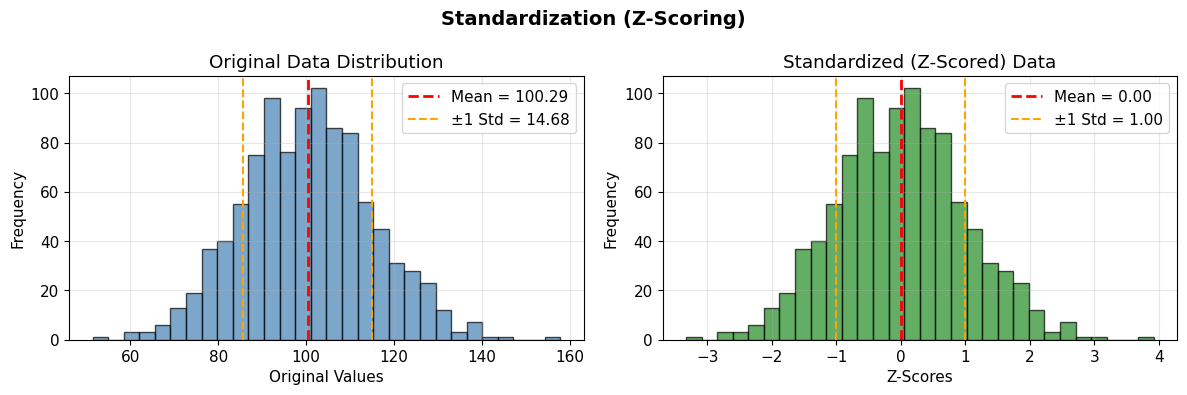

Original: Mean = 100.29, Std = 14.68
Z-scored: Mean = 0.00, Std = 1.00


In [6]:
# Generate sample data
np.random.seed(42)
data = np.random.normal(100, 15, 1000)

# Calculate z-scores
z_scores = (data - np.mean(data)) / np.std(data)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Original data
ax1.hist(data, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(np.mean(data), color='red', linestyle='--', linewidth=2, label=f'Mean = {np.mean(data):.2f}')
ax1.axvline(np.mean(data) + np.std(data), color='orange', linestyle='--', linewidth=1.5, label=f'±1 Std = {np.std(data):.2f}')
ax1.axvline(np.mean(data) - np.std(data), color='orange', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Original Values')
ax1.set_ylabel('Frequency')
ax1.set_title('Original Data Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# Z-scored data
ax2.hist(z_scores, bins=30, color='forestgreen', alpha=0.7, edgecolor='black')
ax2.axvline(np.mean(z_scores), color='red', linestyle='--', linewidth=2, label=f'Mean = {np.mean(z_scores):.2f}')
ax2.axvline(np.mean(z_scores) + np.std(z_scores), color='orange', linestyle='--', linewidth=1.5, label=f'±1 Std = {np.std(z_scores):.2f}')
ax2.axvline(np.mean(z_scores) - np.std(z_scores), color='orange', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Z-Scores')
ax2.set_ylabel('Frequency')
ax2.set_title('Standardized (Z-Scored) Data')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Standardization (Z-Scoring)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Original: Mean = {np.mean(data):.2f}, Std = {np.std(data):.2f}")
print(f"Z-scored: Mean = {np.mean(z_scores):.2f}, Std = {np.std(z_scores):.2f}")

### 2. Gamma Transform (γ = 0.5 and γ = 1.5)

**Verbal Explanation**: Gamma transform amplifies small values (γ < 1) or large values (γ > 1), useful for adjusting feature sensitivity in different ranges.

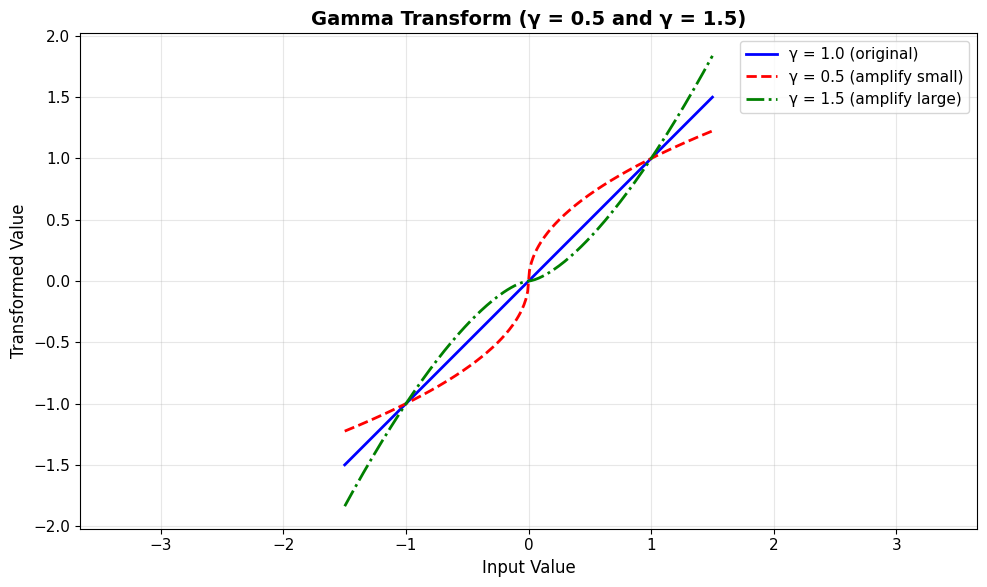

In [6]:
# Generate input range
x = np.linspace(-1.5, 1.5, 200)

# Apply gamma transforms
y_original = x  # gamma = 1
y_gamma_0_5 = np.sign(x) * np.abs(x)**0.5  # gamma = 0.5
y_gamma_1_5 = np.sign(x) * np.abs(x)**1.5  # gamma = 1.5

# Create visualization
plt.figure(figsize=(10, 6))
plt.plot(x, y_original, 'b-', linewidth=2, label='γ = 1.0 (original)')
plt.plot(x, y_gamma_0_5, 'r--', linewidth=2, label='γ = 0.5 (amplify small)')
plt.plot(x, y_gamma_1_5, 'g-.', linewidth=2, label='γ = 1.5 (amplify large)')

plt.xlabel('Input Value', fontsize=12)
plt.ylabel('Transformed Value', fontsize=12)
plt.title('Gamma Transform (γ = 0.5 and γ = 1.5)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

### 3. Clipping / Winsorizing

**Verbal Explanation**: Clipping limits extreme values to reduce the impact of outliers, preventing them from dominating the model.

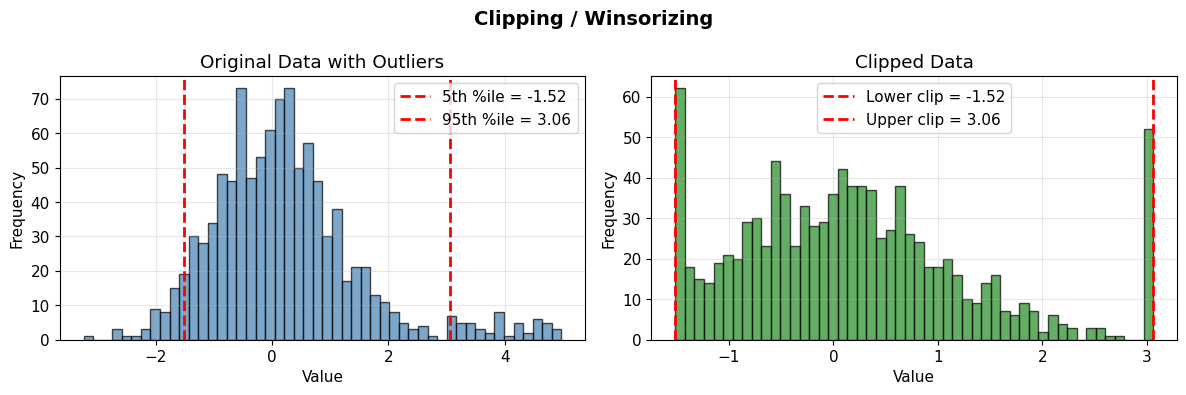

Original range: [-3.24, 4.97]
Clipped range: [-1.52, 3.06]


In [7]:
# Generate data with outliers
np.random.seed(42)
data_with_outliers = np.concatenate([
    np.random.normal(0, 1, 950),
    np.random.uniform(3, 5, 50)
])

# Define clipping thresholds
lower_threshold = np.percentile(data_with_outliers, 5)
upper_threshold = np.percentile(data_with_outliers, 95)

# Apply clipping
clipped_data = np.clip(data_with_outliers, lower_threshold, upper_threshold)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Original data
ax1.hist(data_with_outliers, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(lower_threshold, color='red', linestyle='--', linewidth=2, label=f'5th %ile = {lower_threshold:.2f}')
ax1.axvline(upper_threshold, color='red', linestyle='--', linewidth=2, label=f'95th %ile = {upper_threshold:.2f}')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')
ax1.set_title('Original Data with Outliers')
ax1.legend()
ax1.grid(alpha=0.3)

# Clipped data
ax2.hist(clipped_data, bins=50, color='forestgreen', alpha=0.7, edgecolor='black')
ax2.axvline(lower_threshold, color='red', linestyle='--', linewidth=2, label=f'Lower clip = {lower_threshold:.2f}')
ax2.axvline(upper_threshold, color='red', linestyle='--', linewidth=2, label=f'Upper clip = {upper_threshold:.2f}')
ax2.set_xlabel('Value')
ax2.set_ylabel('Frequency')
ax2.set_title('Clipped Data')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Clipping / Winsorizing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Original range: [{data_with_outliers.min():.2f}, {data_with_outliers.max():.2f}]")
print(f"Clipped range: [{clipped_data.min():.2f}, {clipped_data.max():.2f}]")

### 4. Powers Transform (degree 1, 2, 3)

**Verbal Explanation**: Power transforms create polynomial features, capturing non-linear relationships between inputs and outputs.

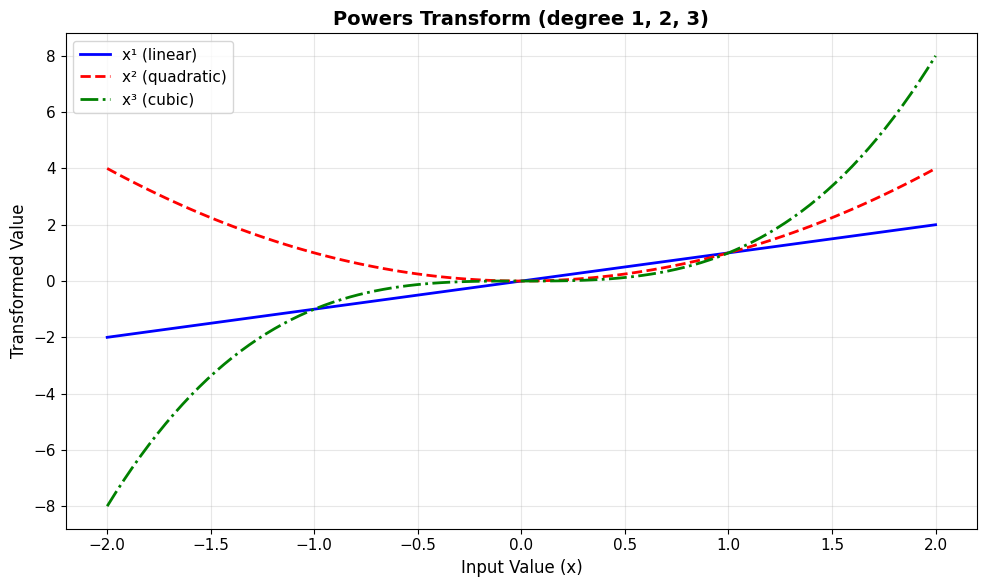

In [8]:
# Generate input data
x = np.linspace(-2, 2, 100)

# Compute powers
x_pow1 = x**1
x_pow2 = x**2
x_pow3 = x**3

# Create visualization
plt.figure(figsize=(10, 6))
plt.plot(x, x_pow1, 'b-', linewidth=2, label='x¹ (linear)')
plt.plot(x, x_pow2, 'r--', linewidth=2, label='x² (quadratic)')
plt.plot(x, x_pow3, 'g-.', linewidth=2, label='x³ (cubic)')

plt.xlabel('Input Value (x)', fontsize=12)
plt.ylabel('Transformed Value', fontsize=12)
plt.title('Powers Transform (degree 1, 2, 3)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

### 5. Positive/Negative Part Split

**Verbal Explanation**: Splitting into positive and negative parts allows the model to learn different behaviors for positive vs negative values of a feature.

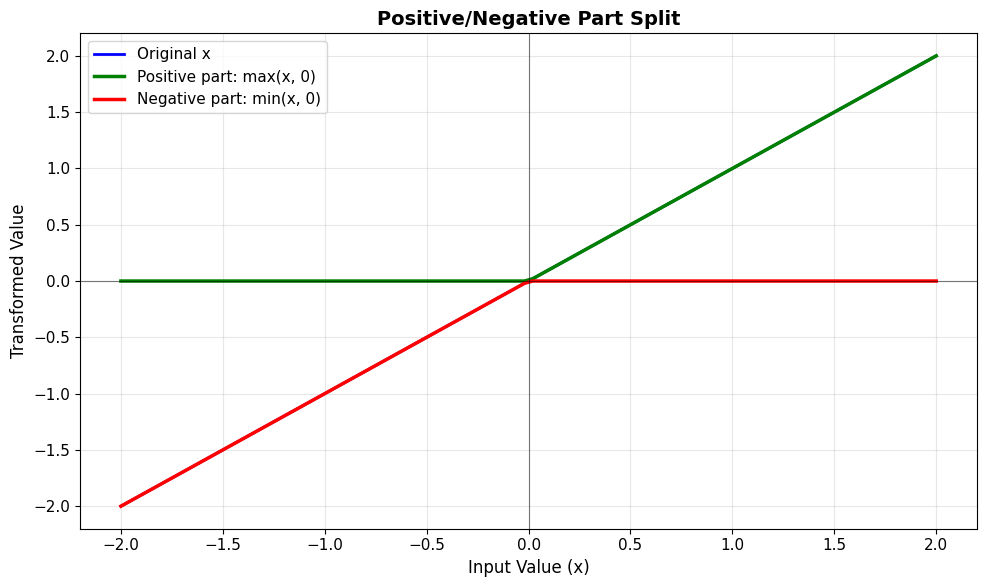

In [9]:
# Generate data spanning negative to positive
x = np.linspace(-2, 2, 100)

# Create positive and negative parts
x_pos = np.maximum(x, 0)
x_neg = np.minimum(x, 0)

# Create visualization
plt.figure(figsize=(10, 6))
plt.plot(x, x, 'b-', linewidth=2, label='Original x')
plt.plot(x, x_pos, 'g-', linewidth=2.5, label='Positive part: max(x, 0)')
plt.plot(x, x_neg, 'r-', linewidth=2.5, label='Negative part: min(x, 0)')
plt.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
plt.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

plt.xlabel('Input Value (x)', fontsize=12)
plt.ylabel('Transformed Value', fontsize=12)
plt.title('Positive/Negative Part Split', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6. Day-of-Week Circular Embedding

**Verbal Explanation**: Circular embedding represents cyclic features like days of the week without imposing false ordering, ensuring Monday and Sunday are treated as adjacent.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


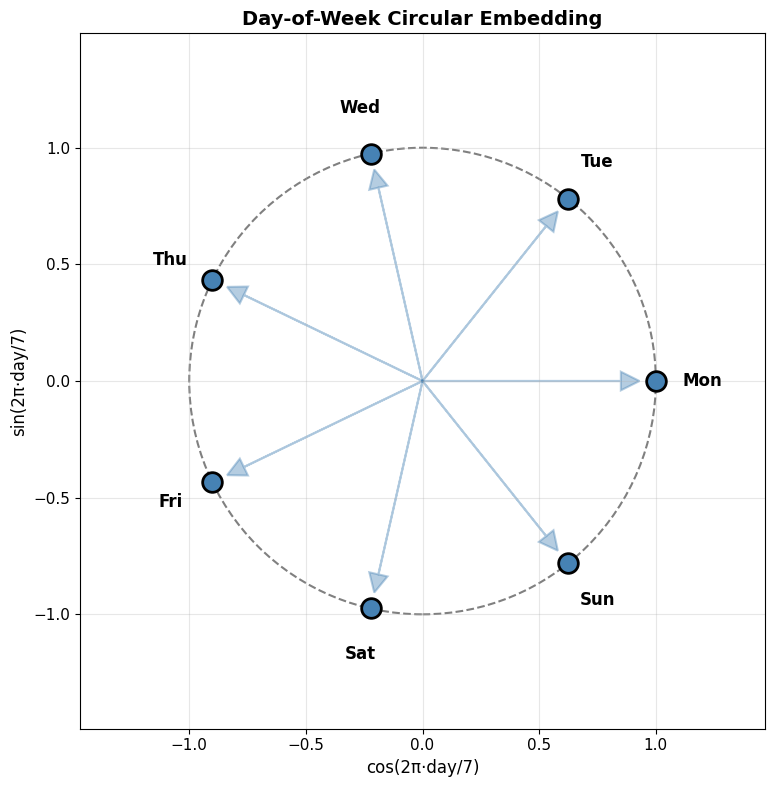


Circular embedding coordinates:
Mon: (1.000, 0.000)
Tue: (0.623, 0.782)
Wed: (-0.223, 0.975)
Thu: (-0.901, 0.434)
Fri: (-0.901, -0.434)
Sat: (-0.223, -0.975)
Sun: (0.623, -0.782)


In [10]:
# Create days array
days = np.arange(0, 7)
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Convert to circular coordinates
x_coords = np.cos(2 * np.pi * days / 7)
y_coords = np.sin(2 * np.pi * days / 7)

# Create visualization
plt.figure(figsize=(8, 8))

# Draw unit circle
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=1.5)
plt.gca().add_patch(circle)

# Plot day points
plt.scatter(x_coords, y_coords, s=200, c='steelblue', edgecolors='black', linewidth=2, zorder=3)

# Add day labels
for i, (x, y, day) in enumerate(zip(x_coords, y_coords, day_names)):
    offset = 0.2
    plt.annotate(day, (x, y), xytext=(x * (1 + offset), y * (1 + offset)),
                fontsize=12, fontweight='bold', ha='center', va='center')
    
# Add arrows from origin to points
for x, y in zip(x_coords, y_coords):
    plt.arrow(0, 0, x * 0.85, y * 0.85, head_width=0.08, head_length=0.08, 
             fc='steelblue', ec='steelblue', alpha=0.4, linewidth=1.5)

plt.xlabel('cos(2π·day/7)', fontsize=12)
plt.ylabel('sin(2π·day/7)', fontsize=12)
plt.title('Day-of-Week Circular Embedding', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.tight_layout()
plt.show()

print("\nCircular embedding coordinates:")
for day, x, y in zip(day_names, x_coords, y_coords):
    print(f"{day}: ({x:.3f}, {y:.3f})")